<a href="https://colab.research.google.com/github/samsyed004/CV-lab/blob/main/lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 05 — HOG-Based Industrial Defect Detection and Classification

Dataset: NEU Surface Defect Database (NEU-DET) — 6 steel-surface defect types: crazing, inclusion, patches, pitted_surface, rolled-in_scale, scratches.



In [1]:
!pip install -q scikit-image opencv-python-headless kaggle joblib

In [2]:
import os, re, glob, time, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

SEED = 42
random.seed(SEED); np.random.seed(SEED)

IMG_SIZE = 128          # common resolution for all images (Task 2)
NORMAL_DIR = None       # optional: path to a folder of defect-free images, e.g. "/content/normal"

## 1. Load and inspect the dataset (Task 1)


In [3]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

os.makedirs("/content/neu", exist_ok=True)
# Corrected dataset slug by adding the missing hyphen
!kaggle datasets download -d sovitrath/neu-steel-surface-defect-detect-trainvalid-split -p /content/neu --unzip -q

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")
all_files = [p for p in glob.glob("/content/neu/**/*", recursive=True) if p.lower().endswith(IMG_EXTS)]
print("Image files found:", len(all_files))
for p in all_files[:5]:
    print("  ", p)

Dataset URL: https://www.kaggle.com/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split
License(s): unknown
Image files found: 1800
   /content/neu/valid_images/rolled-in_scale_7.jpg
   /content/neu/valid_images/inclusion_241.jpg
   /content/neu/valid_images/pitted_surface_19.jpg
   /content/neu/valid_images/pitted_surface_217.jpg
   /content/neu/valid_images/scratches_49.jpg


In [4]:
CLASS_KEYS = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
norm = lambda s: re.sub(r"[^a-z]", "", s.lower())
KEY_NORMS = {norm(k): k for k in CLASS_KEYS}

def label_from_path(path):
    # look at the file name first, then the parent folder name
    for text in (os.path.basename(path), os.path.basename(os.path.dirname(path))):
        t = norm(text)
        for kn, k in KEY_NORMS.items():
            if kn in t:
                return k
    return None

records = [(p, label_from_path(p)) for p in all_files]
records = [(p, l) for p, l in records if l is not None]

if NORMAL_DIR and os.path.isdir(NORMAL_DIR):
    normal_files = [p for p in glob.glob(os.path.join(NORMAL_DIR, "**/*"), recursive=True)
                    if p.lower().endswith(IMG_EXTS)]
    records += [(p, "normal") for p in normal_files]
    print("Added", len(normal_files), "normal images")

if len(records) == 0:
    raise RuntimeError("No labelled images found - check the folder structure printed above "
                       "and adjust label_from_path() to match the file naming.")

df = pd.DataFrame(records, columns=["path", "label"])
classes = sorted(df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df["y"] = df["label"].map(class_to_idx)

print("Classes:", classes)
print(df["label"].value_counts())

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
label
rolled-in_scale    300
inclusion          300
pitted_surface     300
scratches          300
crazing            300
patches            300
Name: count, dtype: int64


In [5]:
def load_gray(path):
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)                         # Task 3: grayscale
    return cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # Task 2: common resolution

imgs, keep = [], []
for i, p in enumerate(df["path"]):
    g = load_gray(p)
    if g is not None:
        imgs.append(g); keep.append(i)
df = df.iloc[keep].reset_index(drop=True)
X_gray = np.array(imgs, dtype=np.uint8)
y_all = df["y"].values
print("Preprocessed array:", X_gray.shape)

Preprocessed array: (1800, 128, 128)


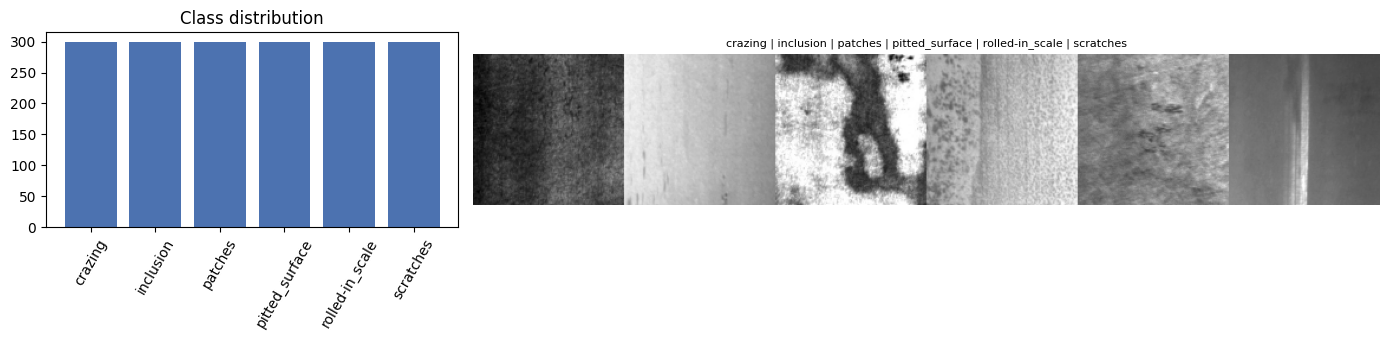

In [6]:
# class distribution + one example per class
counts = df["label"].value_counts().loc[classes]
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), gridspec_kw={"width_ratios": [1, 2.2]})
axes[0].bar(counts.index, counts.values, color="#4C72B0")
axes[0].set_title("Class distribution"); axes[0].tick_params(axis="x", rotation=60)
strip = np.concatenate([X_gray[np.where(y_all == i)[0][0]] for i in range(len(classes))], axis=1)
axes[1].imshow(strip, cmap="gray"); axes[1].axis("off")
axes[1].set_title(" | ".join(classes), fontsize=8)
plt.tight_layout(); plt.savefig("/content/dataset_overview.png", dpi=150); plt.show()

## 2. Train / validation / test split

70/15/15 stratified split. **Validation** is used to choose HOG parameters; **test** is used only once for final reporting.

In [ ]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(y_all))
idx_train, idx_tmp = train_test_split(idx, test_size=0.30, stratify=y_all, random_state=SEED)
idx_val, idx_test = train_test_split(idx_tmp, test_size=0.50, stratify=y_all[idx_tmp], random_state=SEED)

Xg_train, y_train = X_gray[idx_train], y_all[idx_train]
Xg_val,   y_val   = X_gray[idx_val],   y_all[idx_val]
Xg_test,  y_test  = X_gray[idx_test],  y_all[idx_test]
print("Train:", len(y_train), " Val:", len(y_val), " Test:", len(y_test))

Train: 1260  Val: 270  Test: 270


## 3. HOG feature extraction and visualization (Tasks 4–5)

In [7]:
from skimage.feature import hog

def hog_one(im, orient=9, cell=8, block=2, visualize=False):
    return hog(im, orientations=orient, pixels_per_cell=(cell, cell),
               cells_per_block=(block, block), block_norm="L2-Hys",
               feature_vector=True, visualize=visualize)

def extract_hog(images, orient=9, cell=8, block=2):
    feats = Parallel(n_jobs=-1)(delayed(hog_one)(im, orient, cell, block) for im in images)
    return np.array(feats, dtype=np.float32)

print("HOG feature length (cell=8, orient=9):", hog_one(X_gray[0], 9, 8).shape[0])

HOG feature length (cell=8, orient=9): 8100


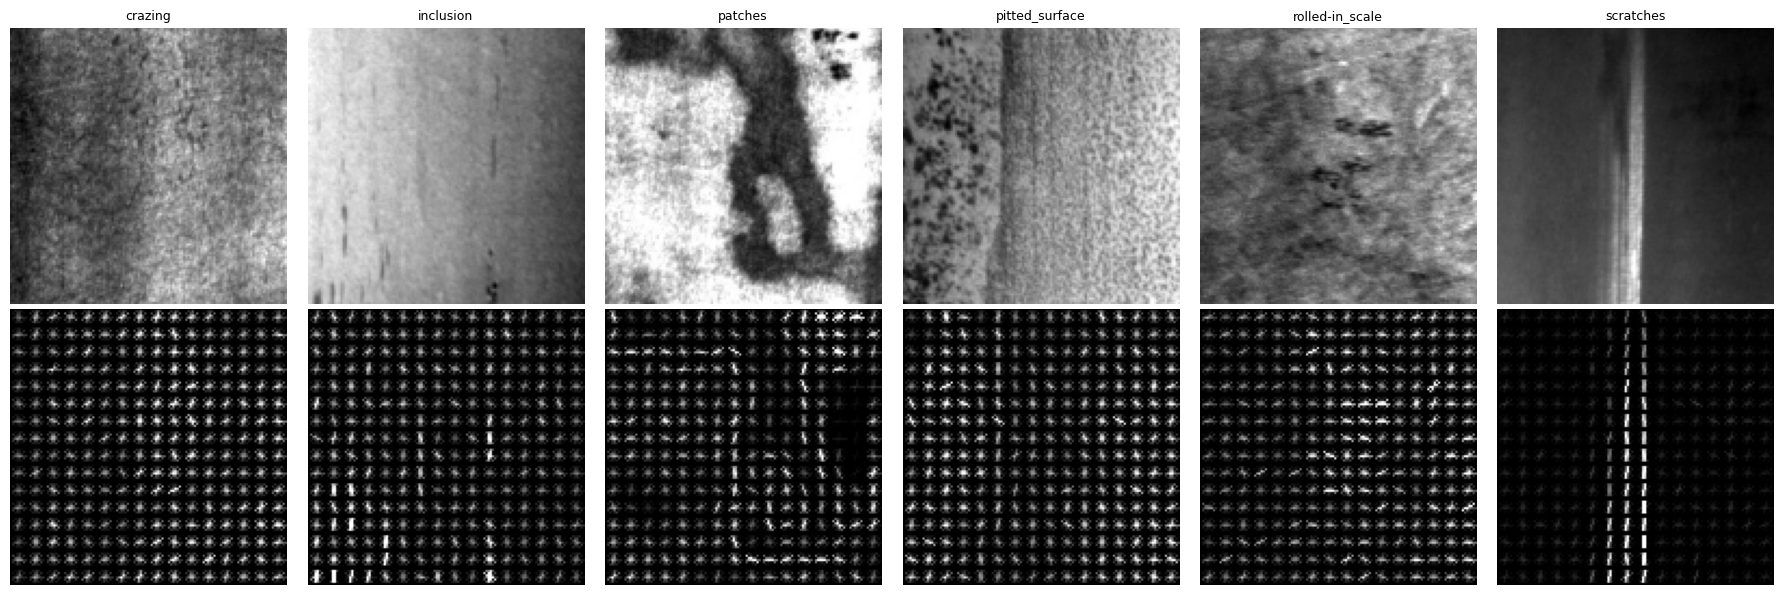

In [ ]:
# Task 5: HOG representation of one representative image per class
from skimage import exposure

fig, axes = plt.subplots(2, len(classes), figsize=(3 * len(classes), 6))
for i, c in enumerate(classes):
    im = X_gray[np.where(y_all == i)[0][0]]
    _, hog_img = hog_one(im, 9, 8, visualize=True)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, np.percentile(hog_img, 99.5) + 1e-8))
    axes[0][i].imshow(im, cmap="gray"); axes[0][i].set_title(c, fontsize=9); axes[0][i].axis("off")
    axes[1][i].imshow(hog_img, cmap="gray"); axes[1][i].axis("off")
axes[0][0].set_ylabel("Grayscale"); axes[1][0].set_ylabel("HOG")
plt.tight_layout(); plt.savefig("/content/hog_visualization.png", dpi=150); plt.show()

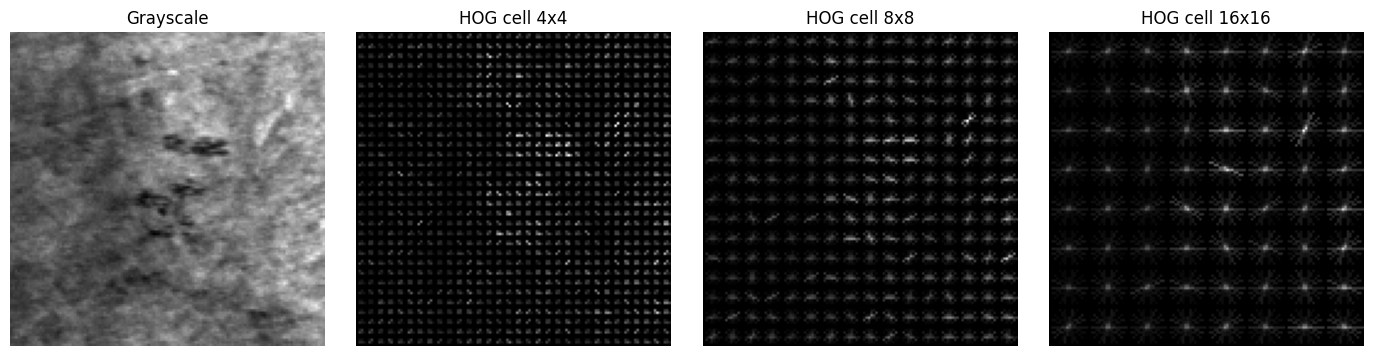

In [ ]:
# Effect of cell size on the HOG picture (same image)
im = X_gray[0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(im, cmap="gray"); axes[0].set_title("Grayscale")
for ax, cell in zip(axes[1:], [4, 8, 16]):
    _, h = hog_one(im, 9, cell, visualize=True)
    ax.imshow(h, cmap="gray"); ax.set_title(f"HOG cell {cell}x{cell}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.savefig("/content/hog_cell_sizes.png", dpi=150); plt.show()

## 4. Metrics helper

In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)

def metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "Recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "F1-score": round(f1_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
    }

## 5. Required experiments — HOG cell size × orientations, HOG+SVM vs HOG+Random Forest (Tasks 6, 7, 8, 11)


In [10]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Ensure train/validation/test split variables exist
if 'Xg_train' not in globals() or 'Xg_val' not in globals():
    print("Split variables not found in workspace. Re-creating splits...")
    idx = np.arange(len(y_all))
    idx_train, idx_tmp = train_test_split(idx, test_size=0.30, stratify=y_all, random_state=SEED)
    idx_val, idx_test = train_test_split(idx_tmp, test_size=0.50, stratify=y_all[idx_tmp], random_state=SEED)

    Xg_train, y_train = X_gray[idx_train], y_all[idx_train]
    Xg_val,   y_val   = X_gray[idx_val],   y_all[idx_val]
    Xg_test,  y_test  = X_gray[idx_test],  y_all[idx_test]

def metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "Recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "F1-score": round(f1_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
    }

CELLS = [4, 8, 16]
ORIENTS = [6, 9, 12]

grid_rows = []
for cell in CELLS:
    for ori in ORIENTS:
        t0 = time.time()
        Xtr = extract_hog(Xg_train, ori, cell)
        Xva = extract_hog(Xg_val, ori, cell)
        feat_time = time.time() - t0

        svm = SVC(kernel="rbf", C=10, gamma="scale").fit(Xtr, y_train)
        m_svm = metrics(y_val, svm.predict(Xva))

        rf = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=SEED).fit(Xtr, y_train)
        m_rf = metrics(y_val, rf.predict(Xva))

        grid_rows.append({"Cell": f"{cell}x{cell}", "Orientations": ori, "Feature dim": Xtr.shape[1],
                          "SVM Acc": m_svm["Accuracy"], "SVM F1": m_svm["F1-score"],
                          "RF Acc": m_rf["Accuracy"], "RF F1": m_rf["F1-score"]})
        print(f"cell {cell:>2} | ori {ori:>2} | dim {Xtr.shape[1]:>6} | "
              f"SVM F1 {m_svm['F1-score']:.2f} | RF F1 {m_rf['F1-score']:.2f}")

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv("/content/hog_parameter_grid.csv", index=False)
grid_df

Split variables not found in workspace. Re-creating splits...
cell  4 | ori  6 | dim  23064 | SVM F1 82.44 | RF F1 58.05
cell  4 | ori  9 | dim  34596 | SVM F1 81.74 | RF F1 55.09
cell  4 | ori 12 | dim  46128 | SVM F1 84.03 | RF F1 58.69
cell  8 | ori  6 | dim   5400 | SVM F1 89.82 | RF F1 75.40
cell  8 | ori  9 | dim   8100 | SVM F1 89.46 | RF F1 71.81
cell  8 | ori 12 | dim  10800 | SVM F1 92.04 | RF F1 77.97
cell 16 | ori  6 | dim   1176 | SVM F1 93.60 | RF F1 86.38
cell 16 | ori  9 | dim   1764 | SVM F1 92.89 | RF F1 87.67
cell 16 | ori 12 | dim   2352 | SVM F1 92.86 | RF F1 90.19


,Cell,Orientations,Feature dim,SVM Acc,SVM F1,RF Acc,RF F1
0,4x4,6,23064,82.96,82.44,60.37,58.05
1,4x4,9,34596,82.22,81.74,57.41,55.09
2,4x4,12,46128,84.44,84.03,59.63,58.69
3,8x8,6,5400,90.00,89.82,76.30,75.40
4,8x8,9,8100,89.63,89.46,72.96,71.81
5,8x8,12,10800,92.22,92.04,78.89,77.97
6,16x16,6,1176,93.70,93.60,86.67,86.38
7,16x16,9,1764,92.96,92.89,88.15,87.67
8,16x16,12,2352,92.96,92.86,90.37,90.19


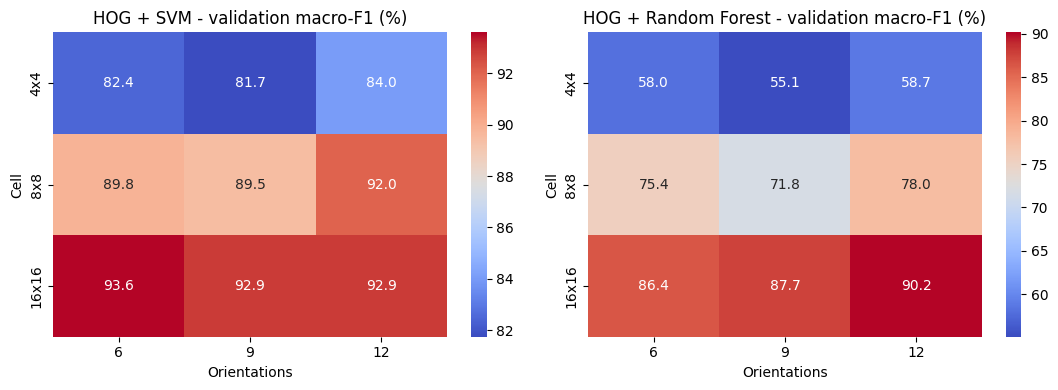

Best HOG config by SVM validation F1: cell 16x16, 6 orientations


In [ ]:
# Heatmaps of validation F1 for each classifier
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ["SVM F1", "RF F1"], ["HOG + SVM", "HOG + Random Forest"]):
    pivot = grid_df.pivot(index="Cell", columns="Orientations", values=col).loc[[f"{c}x{c}" for c in CELLS]]
    # Changed cmap from 'viridis' to 'coolwarm'
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm", ax=ax)
    ax.set_title(f"{title} - validation macro-F1 (%)")
plt.tight_layout(); plt.savefig("/content/hog_parameter_heatmaps.png", dpi=150); plt.show()

best_row = grid_df.loc[grid_df["SVM F1"].idxmax()]
BEST_CELL = int(best_row["Cell"].split("x")[0])
BEST_ORI = int(best_row["Orientations"])
print(f"Best HOG config by SVM validation F1: cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orientations")

## 6. Final models on the test set (Tasks 6–10)

Trained on train+validation with the best HOG configuration, then evaluated once on the held-out test set. SVM, Random Forest and KNN are compared.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

X_trval_g = np.concatenate([Xg_train, Xg_val])
y_trval = np.concatenate([y_train, y_val])

X_trval = extract_hog(X_trval_g, BEST_ORI, BEST_CELL)
X_test_h = extract_hog(Xg_test, BEST_ORI, BEST_CELL)

final_models = {
    "HOG + SVM (RBF)": SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=SEED),
    "HOG + Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "HOG + KNN": KNeighborsClassifier(n_neighbors=5),
}

test_rows, test_preds = [], {}
for name, model in final_models.items():
    t0 = time.time(); model.fit(X_trval, y_trval); train_t = time.time() - t0
    t0 = time.time(); pred = model.predict(X_test_h); infer_ms = (time.time() - t0) / len(pred) * 1000
    test_preds[name] = pred
    test_rows.append({"Model": name, **metrics(y_test, pred),
                      "Train time (s)": round(train_t, 2), "Inference (ms/img)": round(infer_ms, 3)})

test_df = pd.DataFrame(test_rows)
test_df.to_csv("/content/classifier_comparison_test.csv", index=False)
print(f"HOG config: cell {BEST_CELL}x{BEST_CELL}, orientations {BEST_ORI}")
test_df

HOG config: cell 16x16, orientations 6


,Model,Accuracy,Precision,Recall,F1-score,Train time (s),Inference (ms/img)
0,HOG + SVM (RBF),87.41,87.66,87.41,87.26,3.68,1.227
1,HOG + Random Forest,87.04,87.30,87.04,86.89,13.46,0.365
2,HOG + KNN,70.00,76.32,70.00,66.43,0.00,0.283


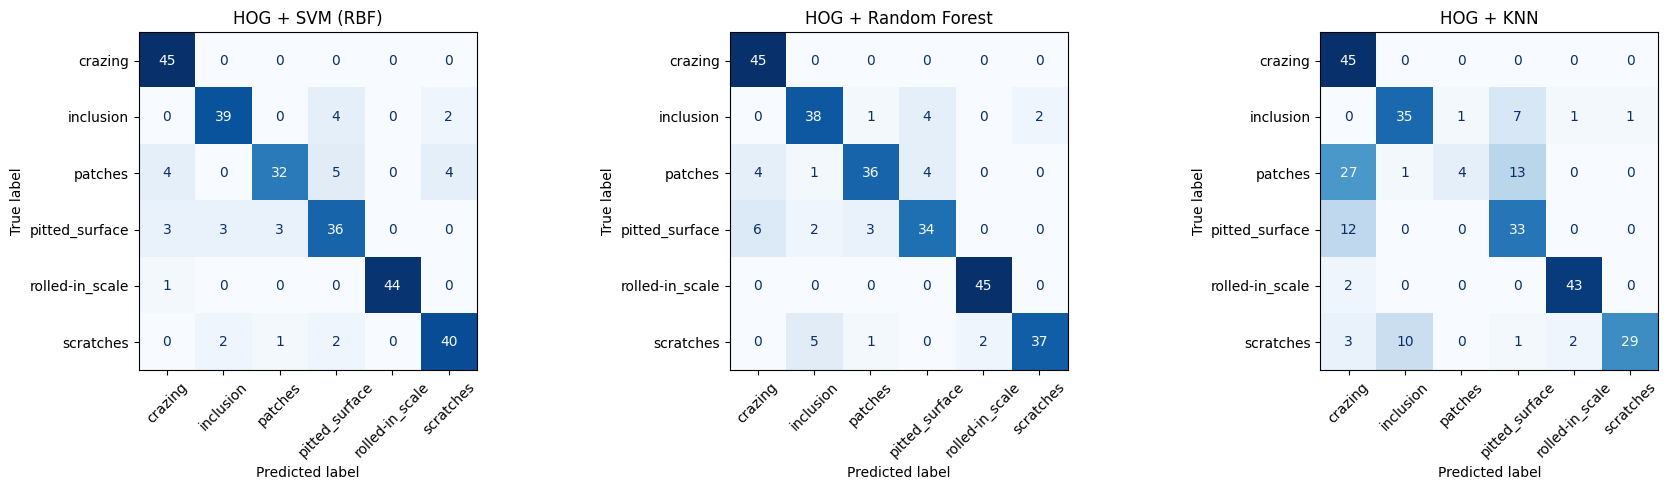

HOG + SVM (RBF)
                 precision    recall  f1-score   support

        crazing       0.85      1.00      0.92        45
      inclusion       0.89      0.87      0.88        45
        patches       0.89      0.71      0.79        45
 pitted_surface       0.77      0.80      0.78        45
rolled-in_scale       1.00      0.98      0.99        45
      scratches       0.87      0.89      0.88        45

       accuracy                           0.87       270
      macro avg       0.88      0.87      0.87       270
   weighted avg       0.88      0.87      0.87       270

HOG + Random Forest
                 precision    recall  f1-score   support

        crazing       0.82      1.00      0.90        45
      inclusion       0.83      0.84      0.84        45
        patches       0.88      0.80      0.84        45
 pitted_surface       0.81      0.76      0.78        45
rolled-in_scale       0.96      1.00      0.98        45
      scratches       0.95      0.82      0.88  

In [ ]:
# Confusion matrix + classification report for every classifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, len(final_models), figsize=(6 * len(final_models), 5))
for ax, (name, pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("/content/confusion_matrices.png", dpi=150); plt.show()

for name, pred in test_preds.items():
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_test, pred, target_names=classes, zero_division=0))

## 7. Robustness analysis (Task 12)

The trained HOG+SVM model is tested (without retraining) on test images degraded by brightness change, Gaussian noise, rotation and blur.

In [ ]:
svm_final = final_models["HOG + SVM (RBF)"]
rng = np.random.default_rng(SEED)

def brightness(im, delta):
    return np.clip(im.astype(np.int16) + delta, 0, 255).astype(np.uint8)

def gauss_noise(im, sigma):
    return np.clip(im.astype(np.float32) + rng.normal(0, sigma, im.shape), 0, 255).astype(np.uint8)

def rotate(im, angle):
    h, w = im.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(im, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def blur(im, k):
    return cv2.GaussianBlur(im, (k, k), 0)

conditions = {
    "Clean (baseline)": lambda im: im,
    "Brightness +40": lambda im: brightness(im, 40),
    "Brightness -40": lambda im: brightness(im, -40),
    "Gaussian noise (sigma=10)": lambda im: gauss_noise(im, 10),
    "Gaussian noise (sigma=25)": lambda im: gauss_noise(im, 25),
    "Rotation 10 deg": lambda im: rotate(im, 10),
    "Rotation 20 deg": lambda im: rotate(im, 20),
    "Blur (k=3)": lambda im: blur(im, 3),
    "Blur (k=7)": lambda im: blur(im, 7),
}

rob_rows = []
for cname, fn in conditions.items():
    degraded = np.array([fn(im) for im in Xg_test])
    pred = svm_final.predict(extract_hog(degraded, BEST_ORI, BEST_CELL))
    m = metrics(y_test, pred)
    rob_rows.append({"Condition": cname, "Accuracy": m["Accuracy"], "F1-score": m["F1-score"]})

rob_df = pd.DataFrame(rob_rows)
base_acc, base_f1 = rob_df.loc[0, "Accuracy"], rob_df.loc[0, "F1-score"]
rob_df["Delta Accuracy"] = (rob_df["Accuracy"] - base_acc).round(2)
rob_df["Delta F1"] = (rob_df["F1-score"] - base_f1).round(2)
rob_df.to_csv("/content/robustness_results.csv", index=False)
rob_df

,Condition,Accuracy,F1-score,Delta Accuracy,Delta F1
0,Clean (baseline),87.41,87.26,0.00,0.00
1,Brightness +40,81.11,80.92,-6.30,-6.34
2,Brightness -40,84.81,84.55,-2.60,-2.71
3,Gaussian noise (sigma=10),27.78,21.63,-59.63,-65.63
4,Gaussian noise (sigma=25),17.78,6.90,-69.63,-80.36
5,Rotation 10 deg,85.19,85.16,-2.22,-2.10
6,Rotation 20 deg,79.63,79.72,-7.78,-7.54
7,Blur (k=3),70.00,68.94,-17.41,-18.32
8,Blur (k=7),21.11,13.33,-66.30,-73.93


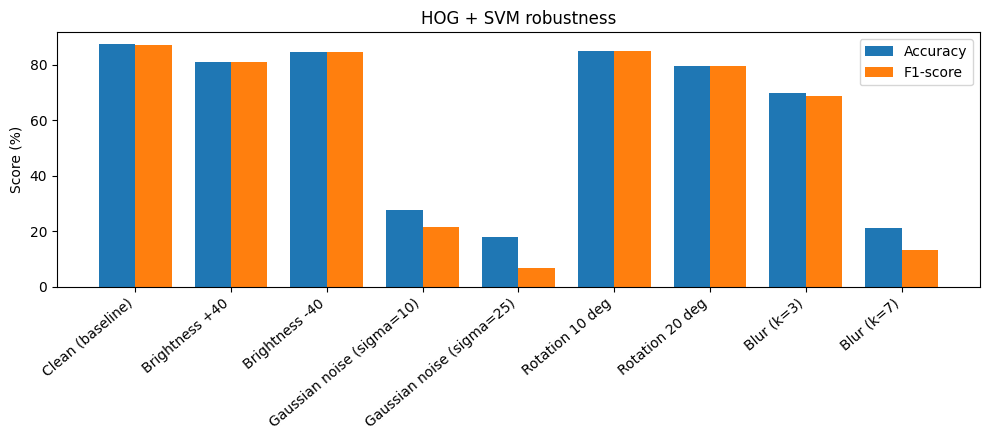

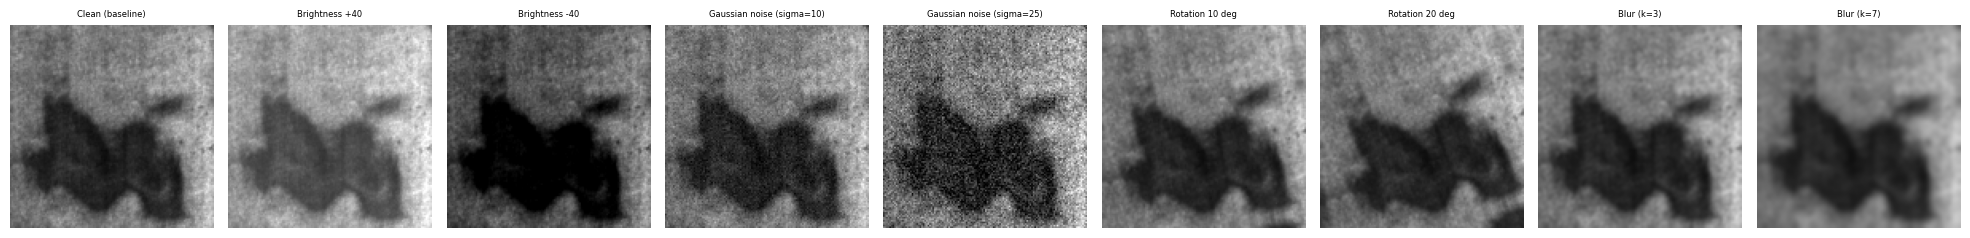

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(rob_df)); w = 0.38
ax.bar(x - w / 2, rob_df["Accuracy"], w, label="Accuracy")
ax.bar(x + w / 2, rob_df["F1-score"], w, label="F1-score")
ax.set_xticks(x); ax.set_xticklabels(rob_df["Condition"], rotation=40, ha="right")
ax.set_ylabel("Score (%)"); ax.set_title("HOG + SVM robustness"); ax.legend()
plt.tight_layout(); plt.savefig("/content/robustness_bars.png", dpi=150); plt.show()

# what the degraded images look like
fig, axes = plt.subplots(1, len(conditions), figsize=(2.2 * len(conditions), 2.6))
for ax, (cname, fn) in zip(axes, conditions.items()):
    ax.imshow(fn(Xg_test[0]), cmap="gray", vmin=0, vmax=255); ax.set_title(cname, fontsize=6); ax.axis("off")
plt.tight_layout(); plt.savefig("/content/robustness_examples.png", dpi=150); plt.show()

## 8. Industrial quality-control decision module (Task 13)

Accepts an image path or a grayscale array and prints the required inspection report. A low-confidence flag is added as a practical safeguard — predictions below `CONF_THRESHOLD` are routed to manual review.

In [ ]:
CONF_THRESHOLD = 0.50

def inspect_product(image, model=svm_final, orient=BEST_ORI, cell=BEST_CELL, show=True):
    if isinstance(image, str):
        gray = load_gray(image)
    else:
        gray = image if image.shape == (IMG_SIZE, IMG_SIZE) else cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    feats = hog_one(gray, orient, cell).reshape(1, -1)
    proba = model.predict_proba(feats)[0]
    k = int(np.argmax(proba)); label = classes[k]; conf = proba[k] * 100

    defective = (label != "normal")
    lines = ["PRODUCT INSPECTION RESULT"]
    if defective:
        lines.append(f"Prediction: DEFECTIVE ({label})")
        lines.append(f"Confidence: {conf:.1f}%")
        lines.append("Action: REJECT PRODUCT")
    else:
        lines.append("Prediction: NON-DEFECTIVE")
        lines.append(f"Confidence: {conf:.1f}%")
        lines.append("Action: ACCEPT PRODUCT")
    if proba[k] < CONF_THRESHOLD:
        lines.append("Note: low confidence - send to manual inspection")
    if show:
        print("\n".join(lines)); print()
    return {"label": label, "confidence": conf, "defective": defective}

# demo: one test image from each class
for c in range(len(classes)):
    i = np.where(y_test == c)[0][0]
    print(f"[true class: {classes[c]}]")
    inspect_product(Xg_test[i])

[true class: crazing]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (crazing)
Confidence: 96.0%
Action: REJECT PRODUCT

[true class: inclusion]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (inclusion)
Confidence: 94.9%
Action: REJECT PRODUCT

[true class: patches]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (patches)
Confidence: 98.5%
Action: REJECT PRODUCT

[true class: pitted_surface]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (pitted_surface)
Confidence: 84.6%
Action: REJECT PRODUCT

[true class: rolled-in_scale]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (rolled-in_scale)
Confidence: 81.5%
Action: REJECT PRODUCT

[true class: scratches]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (scratches)
Confidence: 99.1%
Action: REJECT PRODUCT



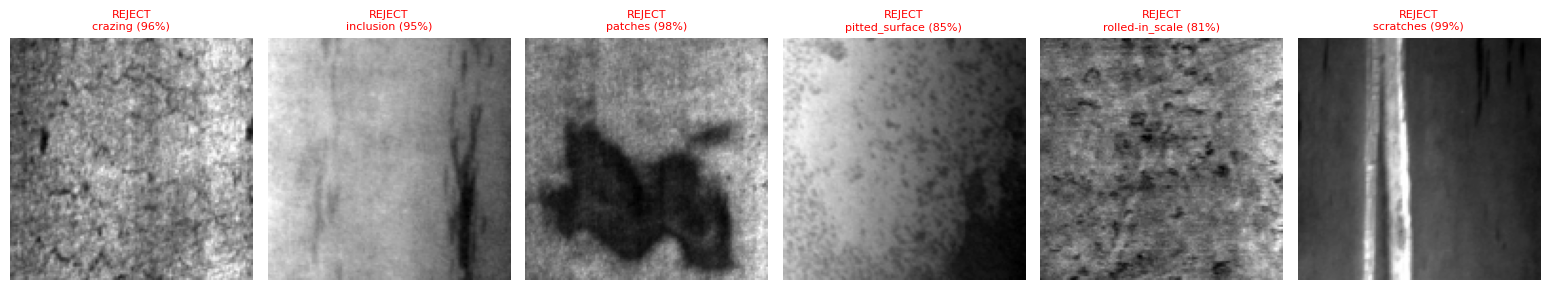

In [ ]:
# visual demo
n = len(classes)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.2))
for c, ax in enumerate(axes):
    i = np.where(y_test == c)[0][0]
    r = inspect_product(Xg_test[i], show=False)
    ax.imshow(Xg_test[i], cmap="gray"); ax.axis("off")
    ax.set_title(("REJECT" if r["defective"] else "ACCEPT") + f"\n{r['label']} ({r['confidence']:.0f}%)",
                 fontsize=8, color="red" if r["defective"] else "green")
plt.tight_layout(); plt.savefig("/content/inspection_demo.png", dpi=150); plt.show()

## 9. Bonus — real-time prototype

Saves the trained model and writes a standalone script. Run the script **on your own computer** (Colab cannot access a local webcam directly): `python realtime_inspection.py` for the webcam or `python realtime_inspection.py video.mp4` for a video file. Press `q` to quit. Needs `pip install opencv-python scikit-image scikit-learn joblib`.

In [ ]:
import joblib

joblib.dump({"model": svm_final, "cfg": {"orient": BEST_ORI, "cell": BEST_CELL, "img_size": IMG_SIZE},
             "classes": classes}, "/content/hog_svm_model.joblib")

SCRIPT = """import sys
import cv2
import joblib
import numpy as np
from skimage.feature import hog

bundle = joblib.load("hog_svm_model.joblib")
model, cfg, classes = bundle["model"], bundle["cfg"], bundle["classes"]

source = 0 if len(sys.argv) < 2 else sys.argv[1]
cap = cv2.VideoCapture(source)

while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (cfg["img_size"], cfg["img_size"]), interpolation=cv2.INTER_AREA)
    feats = hog(gray, orientations=cfg["orient"], pixels_per_cell=(cfg["cell"], cfg["cell"]),
                cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True).reshape(1, -1)
    proba = model.predict_proba(feats)[0]
    k = int(np.argmax(proba))
    label, conf = classes[k], proba[k] * 100
    if label == "normal":
        text, color = "PASS (%.0f%%)" % conf, (0, 200, 0)
    else:
        text, color = "DEFECTIVE: %s (%.0f%%)" % (label, conf), (0, 0, 255)
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.imshow("HOG Inspection", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
"""
with open("/content/realtime_inspection.py", "w") as f:
    f.write(SCRIPT)
print("Saved hog_svm_model.joblib and realtime_inspection.py")

Saved hog_svm_model.joblib and realtime_inspection.py


## 10. Export results

In [ ]:
with pd.ExcelWriter("/content/lab05_results.xlsx") as writer:
    grid_df.to_excel(writer, sheet_name="HOG_Param_Grid_Val", index=False)
    test_df.to_excel(writer, sheet_name="Classifier_Comparison_Test", index=False)
    rob_df.to_excel(writer, sheet_name="Robustness", index=False)

from google.colab import files as colab_files
for f in ["lab05_results.xlsx", "hog_svm_model.joblib", "realtime_inspection.py"]:
    colab_files.download("/content/" + f)